
Step 0: Environment Setup & Drive Mounting



In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Step 1: Dataset Overview & Patient ID Discovery

In [ ]:
import os, glob

DATA_ROOT = "/content/drive/MyDrive/14 MS patients"

# list folders (patients)
patients = sorted([p for p in glob.glob(os.path.join(DATA_ROOT, "*")) if os.path.isdir(p)])
print("Number of patient folders found:", len(patients))
print("\nFirst few patient folders:")
for p in patients[:10]:
    print(" -", os.path.basename(p))


Number of patient folders found: 14

First few patient folders:
 - 00408990
 - 00713519
 - 00960975
 - 00981157
 - 01092669
 - 01386182
 - 01406050
 - 01406050_1
 - 01563167
 - 01581148_2


Step 2: Train / Test Split Definition

In [ ]:
# ===============================
# CHOOSE TRAIN / TEST PATIENTS
# ===============================

TRAIN_ID = "00713519"            # ← put ONE patient ID for training
TEST_IDS = ["00960975", "00981157"]  # ← put TWO patient IDs for testing


Verifying the ids

In [ ]:
print("Training patient:", TRAIN_ID)
print("Testing patients:", TEST_IDS)


Training patient: 00713519
Testing patients: ['00960975', '00981157']


Step 3: Inspect Selected Patient Folders

In [ ]:
# ===============================
# STEP 3 — Inspect chosen patients
# Identify baseline / follow-up / label files
# ===============================

import os, re, glob
from pathlib import Path

# ✅ EDIT THESE
TRAIN_ID = "00713519"
TEST_IDS = ["00960975", "00981157"]

DATA_ROOT = "/content/drive/MyDrive/14 MS patients"


def parse_date_from_name(name: str):
    """
    Extract an 8-digit date (YYYYMMDD) from filename if present.
    Example: 00713519_20181002.nii.gz -> 20181002
    Returns int date or None.
    """
    m = re.search(r"(19|20)\d{6}", name)
    return int(m.group(0)) if m else None


def classify_files(patient_dir: str):
    """
    Returns:
      - baseline_path (earliest dated nii)
      - followup_path (latest dated nii)
      - label_path (best guess by name)
      - other_nii (everything else)
      - mats (mat files)
    """
    nii = sorted(glob.glob(os.path.join(patient_dir, "*.nii.gz")))
    mats = sorted(glob.glob(os.path.join(patient_dir, "*.mat")))

    # candidate label by name
    label_candidates = []
    for f in nii:
        bn = os.path.basename(f).lower()
        if "label" in bn or "seg" in bn or "mask" in bn or "gt" in bn:
            label_candidates.append(f)

    # exclude label candidates from flair candidates
    flair_candidates = [f for f in nii if f not in label_candidates]

    # try to pick baseline/follow-up based on date in filename
    dated = []
    for f in flair_candidates:
        d = parse_date_from_name(os.path.basename(f))
        if d is not None:
            dated.append((d, f))

    baseline = followup = None
    if len(dated) >= 2:
        dated.sort(key=lambda x: x[0])
        baseline = dated[0][1]
        followup = dated[-1][1]
    else:
        # fallback: just take first two as baseline/followup (not ideal, but prints warning)
        if len(flair_candidates) >= 2:
            baseline, followup = flair_candidates[0], flair_candidates[1]

    # pick label: prefer exact "Segmentation-label"
    label = None
    if label_candidates:
        exact = [f for f in label_candidates if "segmentation-label" in os.path.basename(f).lower()]
        label = exact[0] if exact else label_candidates[0]

    other_nii = [f for f in nii if f not in [baseline, followup, label] and f is not None]

    return baseline, followup, label, other_nii, mats


def print_patient_summary(pid: str):
    pdir = os.path.join(DATA_ROOT, pid)
    print("\n" + "="*80)
    print("Patient:", pid)
    print("Folder:", pdir)

    if not os.path.isdir(pdir):
        print("❌ Folder not found.")
        return

    baseline, followup, label, other_nii, mats = classify_files(pdir)

    # List all files first
    all_files = sorted([p.name for p in Path(pdir).glob("*")])
    print("\nAll files in folder:")
    for f in all_files:
        print("  -", f)

    print("\n✅ Detected files:")
    if baseline:
        print("  Baseline  :", os.path.basename(baseline))
    else:
        print("  Baseline  : ⚠️ not detected")

    if followup:
        print("  Follow-up :", os.path.basename(followup))
    else:
        print("  Follow-up : ⚠️ not detected")

    if label:
        print("  Label/GT  :", os.path.basename(label))
    else:
        print("  Label/GT  : ⚠️ not detected (no file with label/seg/mask/gt in name)")

    if mats:
        print("\nMAT files (registration?):")
        for m in mats:
            print("  -", os.path.basename(m))
    else:
        print("\nMAT files: none")

    if other_nii:
        print("\nOther NIfTI files (maybe registered volumes, masks, etc.):")
        for f in other_nii:
            print("  -", os.path.basename(f))
    else:
        print("\nOther NIfTI files: none")


# Run summaries for your split
print("Training patient:", TRAIN_ID)
print("Testing patients:", TEST_IDS)

for pid in [TRAIN_ID] + TEST_IDS:
    print_patient_summary(pid)


Training patient: 00713519
Testing patients: ['00960975', '00981157']

Patient: 00713519
Folder: /content/drive/MyDrive/14 MS patients/00713519

All files in folder:
  - 00713519_20181002.nii.gz
  - 00713519_20190830.nii.gz
  - 00713519_20190830_to_FLAIR_1.nii.gz
  - FLAIR_2_to_FLAIR_1.mat
  - Segmentation-label.nii.gz

✅ Detected files:
  Baseline  : 00713519_20181002.nii.gz
  Follow-up : 00713519_20190830_to_FLAIR_1.nii.gz
  Label/GT  : Segmentation-label.nii.gz

MAT files (registration?):
  - FLAIR_2_to_FLAIR_1.mat

Other NIfTI files (maybe registered volumes, masks, etc.):
  - 00713519_20190830.nii.gz

Patient: 00960975
Folder: /content/drive/MyDrive/14 MS patients/00960975

All files in folder:
  - 00960975_20180222.nii.gz
  - 00960975_20190822.nii.gz
  - 00960975_20190822_to_FLAIR_1.nii.gz
  - FLAIR_2_to_FLAIR_1.mat
  - Segmentation-label.nii.gz

✅ Detected files:
  Baseline  : 00960975_20180222.nii.gz
  Follow-up : 00960975_20190822_to_FLAIR_1.nii.gz
  Label/GT  : Segmentation-l

Sanity Check: Geometry & GT Alignment (Before Preprocessing)

In [ ]:
import os
import nibabel as nib
import numpy as np

DATA_ROOT = "/content/drive/MyDrive/14 MS patients"
TRAIN_ID = "00713519"
TEST_IDS = ["00960975", "00981157"]

def info(path):
    img = nib.load(path)
    shape = img.shape
    zooms = img.header.get_zooms()[:3]
    affine = img.affine
    return shape, zooms, affine

def affine_close(a, b, tol=1e-3):
    return np.allclose(a, b, atol=tol)

def print_geom(pid):
    pdir = os.path.join(DATA_ROOT, pid)

    # expected filenames in your dataset
    files = sorted([f for f in os.listdir(pdir) if f.endswith(".nii.gz")])
    baseline = [f for f in files if "_to_FLAIR_1" not in f and "Segmentation-label" not in f][0]  # earliest baseline usually
    # better: pick earliest date as baseline (works with your naming)
    dated = sorted([(int(f.split("_")[1].split(".")[0]), f) for f in files if re.search(r"(19|20)\d{6}", f) and "_to_FLAIR_1" not in f])
    baseline = dated[0][1]
    followup_original = dated[-1][1]
    followup_to_f1 = [f for f in files if "_to_FLAIR_1" in f][0]
    label = [f for f in files if "Segmentation-label" in f][0]

    paths = {
        "baseline": os.path.join(pdir, baseline),
        "followup_original": os.path.join(pdir, followup_original),
        "followup_to_FLAIR_1": os.path.join(pdir, followup_to_f1),
        "label": os.path.join(pdir, label)
    }

    print("\n" + "="*90)
    print("Patient:", pid)
    for k, p in paths.items():
        sh, z, aff = info(p)
        print(f"{k:18s} | shape={sh} | zooms={z} | file={os.path.basename(p)}")

    # compare geometry
    b_aff = nib.load(paths["baseline"]).affine
    b_shape = nib.load(paths["baseline"]).shape

    f1_aff = nib.load(paths["followup_to_FLAIR_1"]).affine
    f1_shape = nib.load(paths["followup_to_FLAIR_1"]).shape

    l_aff = nib.load(paths["label"]).affine
    l_shape = nib.load(paths["label"]).shape

    print("\nGeometry checks (compared to BASELINE):")
    print("followup_to_FLAIR_1 same shape? ", f1_shape == b_shape)
    print("followup_to_FLAIR_1 same affine? ", affine_close(f1_aff, b_aff))
    print("label same shape?              ", l_shape == b_shape)
    print("label same affine?             ", affine_close(l_aff, b_aff))

import re
for pid in [TRAIN_ID] + TEST_IDS:
    print_geom(pid)



Patient: 00713519
baseline           | shape=(326, 256, 256) | zooms=(np.float32(0.56000054), np.float32(0.9765625), np.float32(0.9765625)) | file=00713519_20181002.nii.gz
followup_original  | shape=(295, 256, 256) | zooms=(np.float32(0.56), np.float32(0.9765625), np.float32(0.9765625)) | file=00713519_20190830.nii.gz
followup_to_FLAIR_1 | shape=(326, 256, 256) | zooms=(np.float32(0.56000054), np.float32(0.9765625), np.float32(0.9765625)) | file=00713519_20190830_to_FLAIR_1.nii.gz
label              | shape=(326, 256, 256) | zooms=(np.float32(0.56000054), np.float32(0.9765625), np.float32(0.9765625)) | file=Segmentation-label.nii.gz

Geometry checks (compared to BASELINE):
followup_to_FLAIR_1 same shape?  True
followup_to_FLAIR_1 same affine?  True
label same shape?               True
label same affine?              True

Patient: 00960975
baseline           | shape=(326, 256, 256) | zooms=(np.float32(0.55999863), np.float32(0.9765625), np.float32(0.9765625)) | file=00960975_20180222.

Preprocessing

Step 4: Preprocessing – Global Target Shape Definition

In [ ]:
import os, re, glob
import nibabel as nib
import numpy as np

DATA_ROOT = "/content/drive/MyDrive/14 MS patients"
TARGET_SPACING = (0.5, 0.5, 0.5)

# Explicitly ignore known bad patients
IGNORE_IDS = {"00408990"}

def parse_date_from_name(name: str):
    m = re.search(r"(19|20)\d{6}", name)
    return int(m.group(0)) if m else None

def pick_followup_original(patient_dir: str):
    nii = [f for f in glob.glob(os.path.join(patient_dir, "*.nii.gz"))]
    candidates = []
    for f in nii:
        bn = os.path.basename(f).lower()
        if "_to_flair_1" in bn:
            continue
        if "segmentation-label" in bn or "label" in bn:
            continue
        d = parse_date_from_name(os.path.basename(f))
        if d is not None:
            candidates.append((d, f))
    if not candidates:
        return None
    candidates.sort(key=lambda x: x[0])
    return candidates[-1][1]

def estimate_resampled_shape(shape, zooms, target_spacing):
    return tuple(
        int(np.round(shape[i] * (zooms[i] / target_spacing[i])))
        for i in range(3)
    )

patient_dirs = sorted([
    os.path.join(DATA_ROOT, d)
    for d in os.listdir(DATA_ROOT)
    if os.path.isdir(os.path.join(DATA_ROOT, d)) and d not in IGNORE_IDS
])

max_shape = (0, 0, 0)
valid_patients = []

for pdir in patient_dirs:
    pid = os.path.basename(pdir)
    fu = pick_followup_original(pdir)

    if fu is None:
        print(f"⚠️ Skipping {pid}: no valid follow-up found")
        continue

    try:
        img = nib.load(fu)
        shape = img.shape[:3]
        zooms = img.header.get_zooms()[:3]
    except Exception as e:
        print(f"⚠️ Skipping {pid}: could not load image ({e})")
        continue

    est = estimate_resampled_shape(shape, zooms, TARGET_SPACING)
    max_shape = tuple(max(max_shape[i], est[i]) for i in range(3))
    valid_patients.append((pid, shape, zooms, est))

print("\n==============================")
print("Valid patients used:", len(valid_patients))
print("TARGET_SPACING:", TARGET_SPACING)
print("TARGET_SHAPE (for padding):", max_shape)

print("\nLargest resampled volumes:")
for pid, shape, zooms, est in sorted(
    valid_patients,
    key=lambda x: x[3][0]*x[3][1]*x[3][2],
    reverse=True
)[:5]:
    print(f"{pid}: original={shape}, zooms={tuple(float(z) for z in zooms)} → est@0.5mm={est}")



Valid patients used: 13
TARGET_SPACING: (0.5, 0.5, 0.5)
TARGET_SHAPE (for padding): (501, 501, 500)

Largest resampled volumes:
01888003: original=(326, 256, 256), zooms=(0.6100000143051147, 0.9765625, 0.9765625) → est@0.5mm=(398, 500, 500)
00960975: original=(310, 256, 256), zooms=(0.6000075340270996, 0.9765625, 0.9765625) → est@0.5mm=(372, 500, 500)
00981157: original=(326, 256, 256), zooms=(0.5600026249885559, 0.9765625, 0.9765625) → est@0.5mm=(365, 500, 500)
01406050_1: original=(256, 256, 326), zooms=(0.9765625, 0.9765625, 0.5600012540817261) → est@0.5mm=(500, 500, 365)
01563167: original=(326, 256, 256), zooms=(0.5600038170814514, 0.9765625, 0.9765625) → est@0.5mm=(365, 500, 500)


Step 5.1(Training ): Preprocessing Execution (NeuroPoly-style, Per Patient)

*   Preprocess ONE training patient
*   This will do, for TRAIN_ID=00713519:


*   Load baseline + follow-up (original) + GT

*  Register baseline → follow-up (follow-up reference, like NeuroPoly)
*  Resample to 0.5mm (both images, plus label with nearest-neighbor)

*   Normalize intensities


*   (Optional) pad (we’ll implement padding in a way that won’t blow memory

















In [ ]:
!pip -q install SimpleITK


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 33.9 MB/s eta 0:00:00


In [ ]:
import os, re, glob
import numpy as np
import SimpleITK as sitk

DATA_ROOT = "/content/drive/MyDrive/14 MS patients"
OUT_ROOT  = "/content/drive/MyDrive/ms_preprocessed"
os.makedirs(OUT_ROOT, exist_ok=True)

TRAIN_ID = "00713519"
TARGET_SPACING = (0.5, 0.5, 0.5)  # (x,y,z) in SimpleITK
# Your computed max shape is (501,501,500) in (z,y,x) notion from nibabel
# We'll NOT force full-volume padding yet (too big). We'll keep it optional.

def parse_date(name):
    m = re.search(r"(19|20)\d{6}", name)
    return int(m.group(0)) if m else None

def get_patient_paths(pid):
    pdir = os.path.join(DATA_ROOT, pid)
    nii = sorted(glob.glob(os.path.join(pdir, "*.nii.gz")))
    label = [f for f in nii if "segmentation-label" in os.path.basename(f).lower()][0]

    # originals (exclude *_to_FLAIR_1 and label)
    orig = []
    for f in nii:
        bn = os.path.basename(f).lower()
        if "segmentation-label" in bn:
            continue
        if "_to_flair_1" in bn:
            continue
        d = parse_date(os.path.basename(f))
        if d is not None:
            orig.append((d, f))
    orig.sort(key=lambda x: x[0])
    baseline = orig[0][1]
    followup = orig[-1][1]
    return baseline, followup, label

def sitk_read(path):
    return sitk.ReadImage(path)

def resample_to_reference(moving, reference, is_label=False):
    interp = sitk.sitkNearestNeighbor if is_label else sitk.sitkLinear
    return sitk.Resample(moving, reference, sitk.Transform(), interp, 0.0, moving.GetPixelID())

def make_reference_with_spacing(ref_img, out_spacing):
    # Create a new reference grid with desired spacing, preserving physical size.
    in_spacing = ref_img.GetSpacing()
    in_size    = ref_img.GetSize()
    out_size = [
        int(np.round(in_size[i] * (in_spacing[i] / out_spacing[i])))
        for i in range(3)
    ]
    out_ref = sitk.Image(out_size, ref_img.GetPixelID())
    out_ref.SetSpacing(out_spacing)
    out_ref.SetDirection(ref_img.GetDirection())
    out_ref.SetOrigin(ref_img.GetOrigin())
    return out_ref

def register_baseline_to_followup(baseline_img, followup_img):
    # Affine registration (good starting point; matches "quasi-rigid" brain idea)
    # Using Mattes MI + multi-resolution
    initial = sitk.CenteredTransformInitializer(
        followup_img, baseline_img, sitk.AffineTransform(3),
        sitk.CenteredTransformInitializerFilter.GEOMETRY
    )

    reg = sitk.ImageRegistrationMethod()
    reg.SetMetricAsMattesMutualInformation(numberOfHistogramBins=32)
    reg.SetMetricSamplingStrategy(reg.RANDOM)
    reg.SetMetricSamplingPercentage(0.01)
    reg.SetInterpolator(sitk.sitkLinear)

    reg.SetOptimizerAsGradientDescent(learningRate=1.0, numberOfIterations=200,
                                      convergenceMinimumValue=1e-6, convergenceWindowSize=10)
    reg.SetOptimizerScalesFromPhysicalShift()

    reg.SetShrinkFactorsPerLevel([4,2,1])
    reg.SetSmoothingSigmasPerLevel([2,1,0])
    reg.SmoothingSigmasAreSpecifiedInPhysicalUnitsOn()

    reg.SetInitialTransform(initial, inPlace=False)
    final_tfm = reg.Execute(followup_img, baseline_img)
    return final_tfm

def zscore_in_mask(vol, mask):
    v = sitk.GetArrayFromImage(vol).astype(np.float32)
    m = sitk.GetArrayFromImage(mask) > 0
    if m.sum() == 0:
        m = v != 0
    vals = v[m]
    mu, sd = float(vals.mean()), float(vals.std() + 1e-6)
    v = (v - mu) / sd
    out = sitk.GetImageFromArray(v)
    out.CopyInformation(vol)
    return out

def simple_foreground_mask(img):
    # quick mask: non-zero / low-percentile threshold
    arr = sitk.GetArrayFromImage(img).astype(np.float32)
    nz = arr[arr > 0]
    if nz.size == 0:
        m = arr != 0
    else:
        thr = np.percentile(nz, 5)
        m = arr > thr
    out = sitk.GetImageFromArray(m.astype(np.uint8))
    out.CopyInformation(img)
    return out

# ---- Run preprocessing for 1 patient ----
baseline_p, followup_p, label_p = get_patient_paths(TRAIN_ID)
print("Baseline:", os.path.basename(baseline_p))
print("Followup:", os.path.basename(followup_p))
print("Label  :", os.path.basename(label_p))

b = sitk_read(baseline_p)
f = sitk_read(followup_p)
gt = sitk_read(label_p)

# 1) Register baseline -> followup space
tfm = register_baseline_to_followup(b, f)
b_reg = sitk.Resample(b, f, tfm, sitk.sitkLinear, 0.0, b.GetPixelID())

# 2) Build 0.5mm reference grid in FOLLOWUP space
ref05 = make_reference_with_spacing(f, TARGET_SPACING)

# 3) Resample followup and registered baseline to 0.5mm grid
f_05 = sitk.Resample(f, ref05, sitk.Transform(), sitk.sitkLinear, 0.0, f.GetPixelID())
b_05 = sitk.Resample(b_reg, ref05, sitk.Transform(), sitk.sitkLinear, 0.0, b.GetPixelID())

# 4) Resample GT to same 0.5mm grid
# IMPORTANT: GT must be in follow-up space for NeuroPoly-style training.
# If your GT is originally in baseline space, it must be warped too.
# We apply the SAME baseline->followup transform to GT *only if GT is baseline-space*.
# Your earlier check showed GT matched BASELINE. So we transform it then resample.
gt_to_followup = sitk.Resample(gt, f, tfm, sitk.sitkNearestNeighbor, 0, gt.GetPixelID())
gt_05 = sitk.Resample(gt_to_followup, ref05, sitk.Transform(), sitk.sitkNearestNeighbor, 0, gt.GetPixelID())

# 5) Normalization (no N4, per professor)
mask = simple_foreground_mask(f_05)
f_norm = zscore_in_mask(f_05, mask)
b_norm = zscore_in_mask(b_05, mask)

# 6) Save outputs
out_dir = os.path.join(OUT_ROOT, TRAIN_ID)
os.makedirs(out_dir, exist_ok=True)

sitk.WriteImage(b_norm, os.path.join(out_dir, "baseline_0p5_registered_to_followup_norm.nii.gz"))
sitk.WriteImage(f_norm, os.path.join(out_dir, "followup_0p5_norm.nii.gz"))
sitk.WriteImage(gt_05,   os.path.join(out_dir, "label_0p5_in_followup_space.nii.gz"))

print("\nSaved to:", out_dir)
print("Done ✅")


Baseline: 00713519_20181002.nii.gz
Followup: 00713519_20190830.nii.gz
Label  : Segmentation-label.nii.gz

Saved to: /content/drive/MyDrive/ms_preprocessed/00713519
Done ✅


We must sanity-check that:









*   baseline_registered_to_followup and followup are aligned
*   label is in the same follow-up space (very important)


*   The label overlaps plausible bright lesion regions (at least visually)
*  So the next step is: visualize a few slices (like your instructor’s GT vs prediction style, but now as an overlay on the follow-up).




Shapes: (330, 500, 500) (330, 500, 500) (330, 500, 500)
GT voxels: 7938
Showing slices: [85, 158, 231]


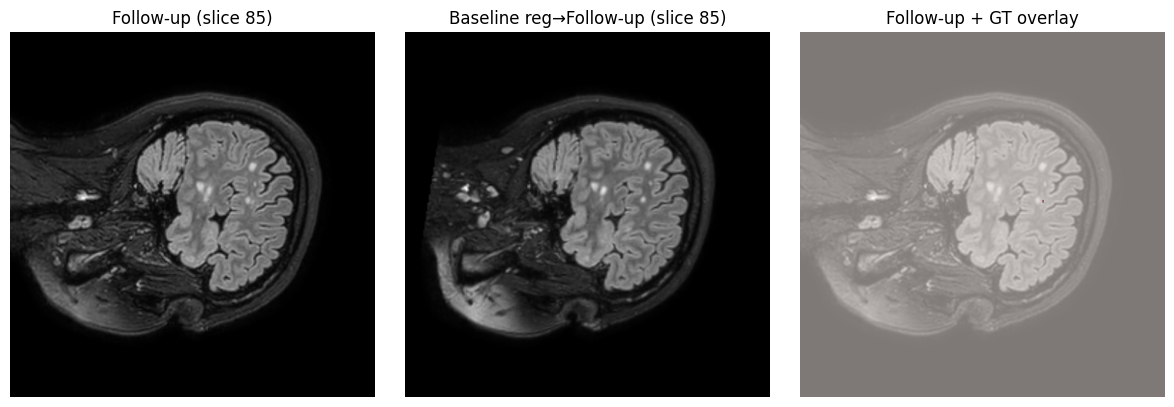

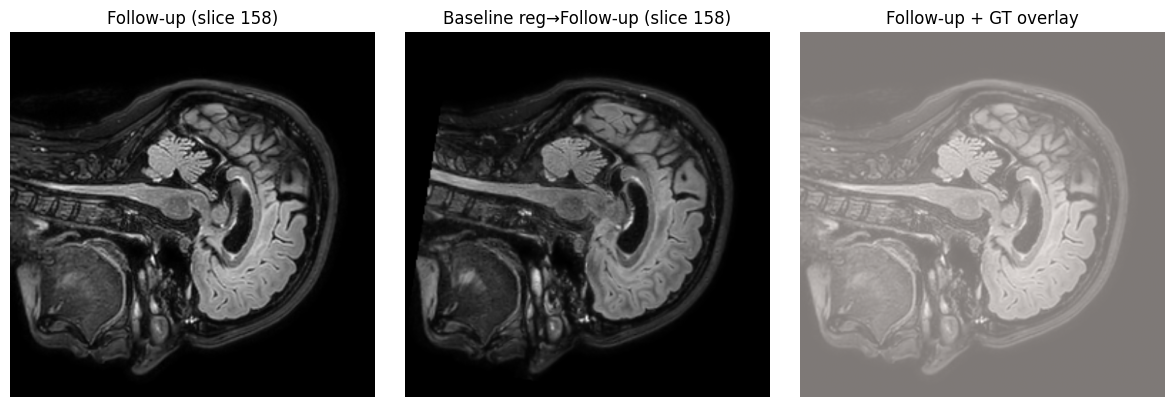

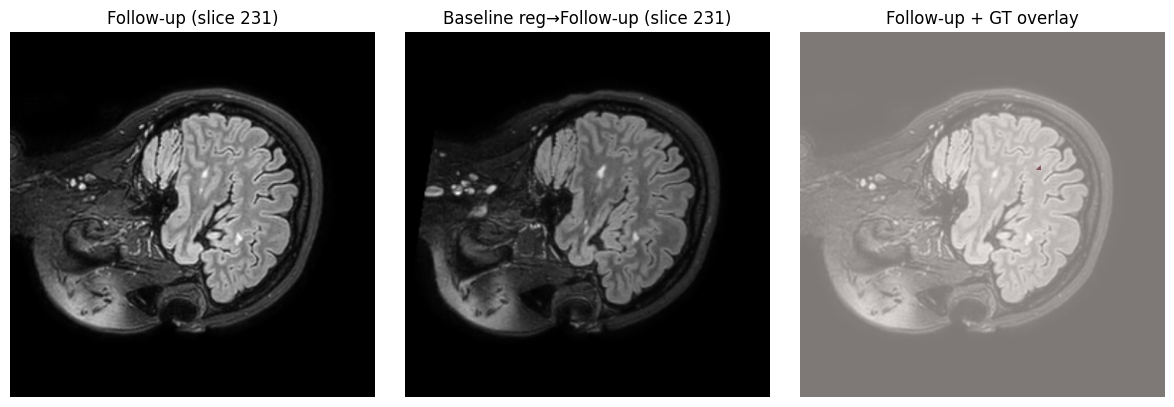

In [ ]:
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

PREP_DIR = "/content/drive/MyDrive/ms_preprocessed/00713519"

f_path  = os.path.join(PREP_DIR, "followup_0p5_norm.nii.gz")
b_path  = os.path.join(PREP_DIR, "baseline_0p5_registered_to_followup_norm.nii.gz")
gt_path = os.path.join(PREP_DIR, "label_0p5_in_followup_space.nii.gz")

f = nib.load(f_path).get_fdata().astype(np.float32)
b = nib.load(b_path).get_fdata().astype(np.float32)
gt = nib.load(gt_path).get_fdata()

gt_bin = gt > 0.5

print("Shapes:", f.shape, b.shape, gt_bin.shape)
print("GT voxels:", int(gt_bin.sum()))

# pick slices that contain GT
z_sums = gt_bin.sum(axis=(1,2))
idx = np.where(z_sums > 0)[0]

if idx.size == 0:
    print("⚠️ No GT voxels after warping/resampling. Something is wrong.")
else:
    # choose up to 3 representative slices
    chosen = np.linspace(idx.min(), idx.max(), 3).astype(int)
    print("Showing slices:", chosen.tolist())

    for sl in chosen:
        fig, ax = plt.subplots(1, 3, figsize=(12, 4))

        ax[0].imshow(f[sl,:,:], cmap="gray")
        ax[0].set_title(f"Follow-up (slice {sl})")
        ax[0].axis("off")

        ax[1].imshow(b[sl,:,:], cmap="gray")
        ax[1].set_title(f"Baseline reg→Follow-up (slice {sl})")
        ax[1].axis("off")

        # overlay GT on follow-up
        ax[2].imshow(f[sl,:,:], cmap="gray")
        ax[2].imshow(gt_bin[sl,:,:], alpha=0.5, cmap="Reds")
        ax[2].set_title("Follow-up + GT overlay")
        ax[2].axis("off")

        plt.tight_layout()
        plt.show()


Conclusion for above :




*   Baseline scans were rigidly registered to follow-up scans.

*   All images were resampled to 0.5 mm isotropic resolution, intensity-normalized, and padded to a common spatial size.
*    Ground-truth lesion masks were transformed into the follow-up reference space






Step 5.2: Preprocess Test Patients

In [ ]:
TEST_IDS = ["00960975", "00981157"]

for pid in TEST_IDS:
    print("\n" + "="*80)
    print("Preprocessing TEST patient:", pid)

    out_dir = os.path.join(OUT_ROOT, pid)
    os.makedirs(out_dir, exist_ok=True)

    baseline_p, followup_p, label_p = get_patient_paths(pid)

    b = sitk_read(baseline_p)
    f = sitk_read(followup_p)
    gt = sitk_read(label_p)

    # Register baseline → follow-up
    tfm = register_baseline_to_followup(b, f)
    b_reg = sitk.Resample(b, f, tfm, sitk.sitkLinear, 0.0, b.GetPixelID())

    # 0.5mm reference grid in follow-up space
    ref05 = make_reference_with_spacing(f, TARGET_SPACING)

    # Resample images
    f_05 = sitk.Resample(f, ref05, sitk.Transform(), sitk.sitkLinear, 0.0, f.GetPixelID())
    b_05 = sitk.Resample(b_reg, ref05, sitk.Transform(), sitk.sitkLinear, 0.0, b.GetPixelID())

    # Warp GT → follow-up, then resample
    gt_to_followup = sitk.Resample(gt, f, tfm, sitk.sitkNearestNeighbor, 0, gt.GetPixelID())
    gt_05 = sitk.Resample(gt_to_followup, ref05, sitk.Transform(), sitk.sitkNearestNeighbor, 0, gt.GetPixelID())

    # Normalize (no N4)
    mask = simple_foreground_mask(f_05)
    f_norm = zscore_in_mask(f_05, mask)
    b_norm = zscore_in_mask(b_05, mask)

    # Save
    sitk.WriteImage(b_norm, os.path.join(out_dir, "baseline_0p5_registered_to_followup_norm.nii.gz"))
    sitk.WriteImage(f_norm, os.path.join(out_dir, "followup_0p5_norm.nii.gz"))
    sitk.WriteImage(gt_05,   os.path.join(out_dir, "label_0p5_in_followup_space.nii.gz"))

    print("Saved to:", out_dir)

print("\nAll TEST patients preprocessed ✅")



Preprocessing TEST patient: 00960975
Saved to: /content/drive/MyDrive/ms_preprocessed/00960975

Preprocessing TEST patient: 00981157
Saved to: /content/drive/MyDrive/ms_preprocessed/00981157

All TEST patients preprocessed ✅


Step 6: Patch Dataset Construction (Training Only)

 build a patch dataset + dataloader from the preprocessed training patient

Input patch = (2, D, H, W) (baseline + followup as channels)

Target patch = (1, D, H, W) (new lesions)

Balanced sampling: 50% positive patches, 50% negative patches

Then we train Pipeline #1: Modified 3D U-Net

Step 6.1: Install & Import Deep Learning Libraries

In [ ]:
!pip -q install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121


In [ ]:
import os
import numpy as np
import nibabel as nib
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader


Step 6.2: Patch Dataset Parameters and Balanced Patch Dataset (On-the-Fly Sampling)

In [ ]:
PREP_ROOT = "/content/drive/MyDrive/ms_preprocessed"
TRAIN_ID = "00713519"

PATCH_SIZE = (64, 64, 64)
STRIDE = (32, 32, 32)   # typical: half the patch size

SAMPLES_PER_EPOCH = 400  # start small (increase later)
POS_FRACTION = 0.5       # 50% positive patches

def load_preprocessed(pid):
    pdir = os.path.join(PREP_ROOT, pid)
    b = nib.load(os.path.join(pdir, "baseline_0p5_registered_to_followup_norm.nii.gz")).get_fdata().astype(np.float32)
    f = nib.load(os.path.join(pdir, "followup_0p5_norm.nii.gz")).get_fdata().astype(np.float32)
    y = nib.load(os.path.join(pdir, "label_0p5_in_followup_space.nii.gz")).get_fdata()
    y = (y > 0.5).astype(np.uint8)
    return b, f, y

def valid_patch_bounds(shape, patch):
    D,H,W = shape
    pd,ph,pw = patch
    return (D-pd, H-ph, W-pw)

class BalancedPatchDataset(Dataset):
    def __init__(self, b, f, y, patch_size=(64,64,64), samples_per_epoch=400, pos_fraction=0.5):
        self.b = b; self.f = f; self.y = y
        self.patch = patch_size
        self.N = samples_per_epoch
        self.pos_fraction = pos_fraction

        # Precompute lesion voxel coordinates for positive sampling
        self.pos_coords = np.argwhere(self.y > 0)
        self.has_pos = (self.pos_coords.shape[0] > 0)

        self.maxz, self.maxy, self.maxx = valid_patch_bounds(self.b.shape, self.patch)

    def __len__(self):
        return self.N

    def _random_start(self):
        z = np.random.randint(0, self.maxz + 1)
        y = np.random.randint(0, self.maxy + 1)
        x = np.random.randint(0, self.maxx + 1)
        return z,y,x

    def _pos_start_centered(self):
        # pick a random lesion voxel and center patch around it (clipped to bounds)
        cz, cy, cx = self.pos_coords[np.random.randint(0, len(self.pos_coords))]
        pd, ph, pw = self.patch
        z = int(np.clip(cz - pd//2, 0, self.maxz))
        y = int(np.clip(cy - ph//2, 0, self.maxy))
        x = int(np.clip(cx - pw//2, 0, self.maxx))
        return z,y,x

    def __getitem__(self, idx):
        want_pos = (np.random.rand() < self.pos_fraction) and self.has_pos

        if want_pos:
            z,y,x = self._pos_start_centered()
        else:
            z,y,x = self._random_start()

        pd,ph,pw = self.patch
        b_patch = self.b[z:z+pd, y:y+ph, x:x+pw]
        f_patch = self.f[z:z+pd, y:y+ph, x:x+pw]
        y_patch = self.y[z:z+pd, y:y+ph, x:x+pw]

        X = np.stack([b_patch, f_patch], axis=0)          # (2, D, H, W)
        Y = y_patch[None, ...].astype(np.float32)         # (1, D, H, W)

        return torch.from_numpy(X), torch.from_numpy(Y)

b, f, y = load_preprocessed(TRAIN_ID)
train_ds = BalancedPatchDataset(b, f, y, PATCH_SIZE, SAMPLES_PER_EPOCH, POS_FRACTION)
train_loader = DataLoader(train_ds, batch_size=2, shuffle=True, num_workers=0, pin_memory=True)

print("Train volume shape:", b.shape)
print("Example batch shapes:", next(iter(train_loader))[0].shape, next(iter(train_loader))[1].shape)


Train volume shape: (330, 500, 500)
Example batch shapes: torch.Size([2, 2, 64, 64, 64]) torch.Size([2, 1, 64, 64, 64])


Step 7: Model and Training (NeuroPoly Pipeline #1)

Step 7.1: Model Architecture — Modified 3D U-Net (Pipeline #1)

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv3d(in_ch, out_ch, 3, padding=1)
        self.in1   = nn.InstanceNorm3d(out_ch)
        self.conv2 = nn.Conv3d(out_ch, out_ch, 3, padding=1)
        self.in2   = nn.InstanceNorm3d(out_ch)
        self.act   = nn.LeakyReLU(0.01, inplace=True)

    def forward(self, x):
        x = self.act(self.in1(self.conv1(x)))
        x = self.act(self.in2(self.conv2(x)))
        return x

class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.down = nn.Conv3d(in_ch, out_ch, kernel_size=3, stride=2, padding=1)  # strided conv downsample
        self.in0  = nn.InstanceNorm3d(out_ch)
        self.act  = nn.LeakyReLU(0.01, inplace=True)
        self.block = ConvBlock(out_ch, out_ch)

    def forward(self, x):
        x = self.act(self.in0(self.down(x)))
        x = self.block(x)
        return x

class Up(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode="nearest")
        self.conv1x1 = nn.Conv3d(in_ch, out_ch, kernel_size=1)      # match dims after up
        self.skip1x1 = nn.Conv3d(skip_ch, out_ch, kernel_size=1)    # match skip dims
        self.block = ConvBlock(out_ch*2, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        x = self.conv1x1(x)
        skip = self.skip1x1(skip)
        x = torch.cat([skip, x], dim=1)
        return self.block(x)

class ModifiedUNet3D(nn.Module):
    def __init__(self, in_ch=2, base=16):
        super().__init__()
        self.enc0 = ConvBlock(in_ch, base)
        self.enc1 = Down(base, base*2)
        self.enc2 = Down(base*2, base*4)
        self.enc3 = Down(base*4, base*8)

        self.bottleneck = Down(base*8, base*16)

        self.dec3 = Up(base*16, base*8, base*8)
        self.dec2 = Up(base*8,  base*4, base*4)
        self.dec1 = Up(base*4,  base*2, base*2)
        self.dec0 = Up(base*2,  base,   base)

        self.out = nn.Conv3d(base, 1, kernel_size=1)

    def forward(self, x):
        s0 = self.enc0(x)
        s1 = self.enc1(s0)
        s2 = self.enc2(s1)
        s3 = self.enc3(s2)
        b  = self.bottleneck(s3)
        x  = self.dec3(b, s3)
        x  = self.dec2(x, s2)
        x  = self.dec1(x, s1)
        x  = self.dec0(x, s0)
        return self.out(x)  # logits


Step 7.2-A: Loss Function and Evaluation Metric

In [ ]:
import os
import numpy as np
import torch

# -------- Dice loss (train) --------
def soft_dice_loss(logits, targets, eps=1e-6):
    probs = torch.sigmoid(logits)
    num = 2 * (probs * targets).sum(dim=(2, 3, 4))
    den = (probs + targets).sum(dim=(2, 3, 4)) + eps
    dice = num / den
    return 1 - dice.mean()

# -------- Dice score (eval metric) --------
def dice_score(pred, gt, eps=1e-8):
    pred = pred.astype(bool)
    gt = gt.astype(bool)
    inter = np.logical_and(pred, gt).sum()
    denom = pred.sum() + gt.sum()
    return (2.0 * inter + eps) / (denom + eps)

# -------- Device / Model / Optimizer --------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ModifiedUNet3D(in_ch=2, base=16).to(device)

opt = torch.optim.Adam(model.parameters(), lr=1e-4)

print("Device:", device)

# -------- Training plan --------
EVAL_EPOCHS = {25, 50, 100, 200}
MAX_EPOCHS = 200
TEST_IDS = ["00960975", "00981157"]
# -------- Sliding-window inference (TEST-time) --------
def sliding_window_predict(b, f, patch_size=(64,64,64), stride=(32,32,32)):
    model.eval()
    D, H, W = b.shape
    pd, ph, pw = patch_size
    sd, sh, sw = stride

    prob = np.zeros((D, H, W), dtype=np.float32)
    count = np.zeros((D, H, W), dtype=np.float32)

    with torch.no_grad():
        for z in range(0, D - pd + 1, sd):
            for y in range(0, H - ph + 1, sh):
                for x in range(0, W - pw + 1, sw):
                    b_patch = b[z:z+pd, y:y+ph, x:x+pw]
                    f_patch = f[z:z+pd, y:y+ph, x:x+pw]

                    X = np.stack([b_patch, f_patch], axis=0)[None]
                    X = torch.from_numpy(X).to(device)

                    logits = model(X)
                    p = torch.sigmoid(logits)[0,0].cpu().numpy()

                    prob[z:z+pd, y:y+ph, x:x+pw] += p
                    count[z:z+pd, y:y+ph, x:x+pw] += 1

    count[count == 0] = 1
    return prob / count


def evaluate_on_tests(model, thr=0.5):
    model.eval()
    results = {}
    with torch.no_grad():
        for pid in TEST_IDS:
            b, f, gt = load_preprocessed(pid)  # from Step 6.2
            prob = sliding_window_predict(
                b, f,
                patch_size=PATCH_SIZE,  # from Step 6.2
                stride=STRIDE           # defined earlier
            )
            pred = (prob >= thr).astype(np.uint8)
            results[pid] = dice_score(pred, gt)
    model.train()
    return results

# checkpoint folder
CKPT_DIR = "/content/drive/MyDrive/ms_preprocessed/_checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)

print("✅ Setup complete. Run Step 7.2-B only when you want to train/resume.")


Device: cuda
✅ Setup complete. Run Step 7.2-B only when you want to train/resume.


Step 7.2-B: Training Loop (ONLY run when TRAIN=True) + Resume support

In [ ]:
# ---------------- TRAINING CELL ----------------
TRAIN = True          # True only when you want to train
RESUME = True         # True to resume from a saved checkpoint
RESUME_EPOCH = 25     # resume from unet_epoch25.pt (must exist in CKPT_DIR)

history = []  # stores (epoch, train_loss, test_scores)

if TRAIN:
    start_epoch = 1

    if RESUME:
        ckpt_path = os.path.join(CKPT_DIR, f"unet_epoch{RESUME_EPOCH}.pt")
        if not os.path.exists(ckpt_path):
            raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}")

        ckpt = torch.load(
            ckpt_path,
            map_location=device,
            weights_only=False
        )

        model.load_state_dict(ckpt["model_state"])
        opt.load_state_dict(ckpt["opt_state"])
        start_epoch = int(ckpt["epoch"]) + 1
        print(f"✅ Resuming training from epoch {start_epoch} (loaded {ckpt_path})")
    else:
        print("✅ Training from scratch")

    model.train()
    for epoch in range(start_epoch, MAX_EPOCHS + 1):
        losses = []

        for X, Y in train_loader:  # train_loader from Step 6.2
            X = X.to(device, non_blocking=True)
            Y = Y.to(device, non_blocking=True)

            opt.zero_grad()
            logits = model(X)
            loss = soft_dice_loss(logits, Y)
            loss.backward()
            opt.step()

            losses.append(loss.item())

        mean_loss = float(np.mean(losses))

        # progress prints (optional)
        if epoch % 5 == 0 or epoch in EVAL_EPOCHS:
            print(f"Epoch {epoch:3d} | train Dice-loss: {mean_loss:.4f}")

        # evaluate + save checkpoints at selected epochs
        if epoch in EVAL_EPOCHS:
            scores = evaluate_on_tests(model, thr=0.5)
            print(f"  ✅ Test Dice @ epoch {epoch}: {scores}")

            history.append((epoch, mean_loss, scores))

            save_path = os.path.join(CKPT_DIR, f"unet_epoch{epoch}.pt")
            torch.save({
                "epoch": epoch,
                "model_state": model.state_dict(),
                "opt_state": opt.state_dict(),
                "train_dice_loss": mean_loss,
                "test_dice": scores
            }, save_path)
            print("  Saved:", save_path)

    print("\nTraining complete ✅")

else:
    print("TRAIN=False → Skipping training loop ✅")
    print("If you want to train/resume, set TRAIN=True in this cell.")


✅ Resuming training from epoch 26 (loaded /content/drive/MyDrive/ms_preprocessed/_checkpoints/unet_epoch25.pt)
Epoch  30 | train Dice-loss: 0.8196
Epoch  35 | train Dice-loss: 0.7607
Epoch  40 | train Dice-loss: 0.7090
Epoch  45 | train Dice-loss: 0.6554
Epoch  50 | train Dice-loss: 0.6244
  ✅ Test Dice @ epoch 50: {'00960975': np.float64(0.035690311031627744), '00981157': np.float64(0.10450210608859208)}
  Saved: /content/drive/MyDrive/ms_preprocessed/_checkpoints/unet_epoch50.pt
Epoch  55 | train Dice-loss: 0.5909
Epoch  60 | train Dice-loss: 0.5624
Epoch  65 | train Dice-loss: 0.5619
Epoch  70 | train Dice-loss: 0.4956
Epoch  75 | train Dice-loss: 0.4940
Epoch  80 | train Dice-loss: 0.4907
Epoch  85 | train Dice-loss: 0.4664
Epoch  90 | train Dice-loss: 0.4471
Epoch  95 | train Dice-loss: 0.4927
Epoch 100 | train Dice-loss: 0.4608
  ✅ Test Dice @ epoch 100: {'00960975': np.float64(0.08008647126864409), '00981157': np.float64(0.15208022004219954)}
  Saved: /content/drive/MyDrive/ms_p

Step 7.3: Visual Evaluation — Ground Truth vs Prediction

✅ Loaded checkpoint from epoch 50


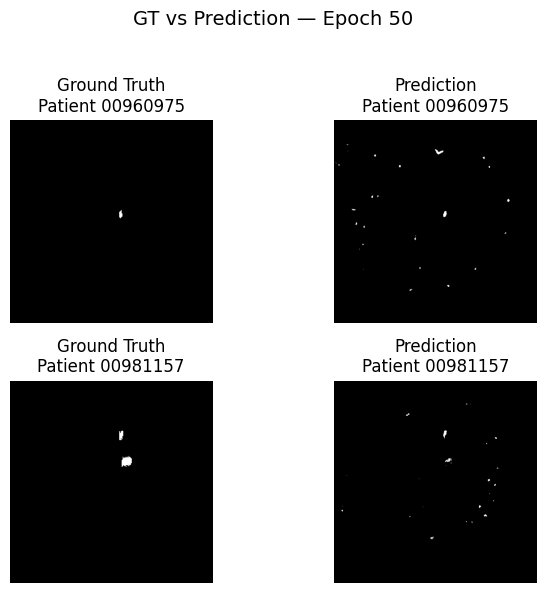

💾 Saved: /content/drive/MyDrive/ms_preprocessed/_visual_results/GT_vs_Pred_epoch50.png
✅ Loaded checkpoint from epoch 100


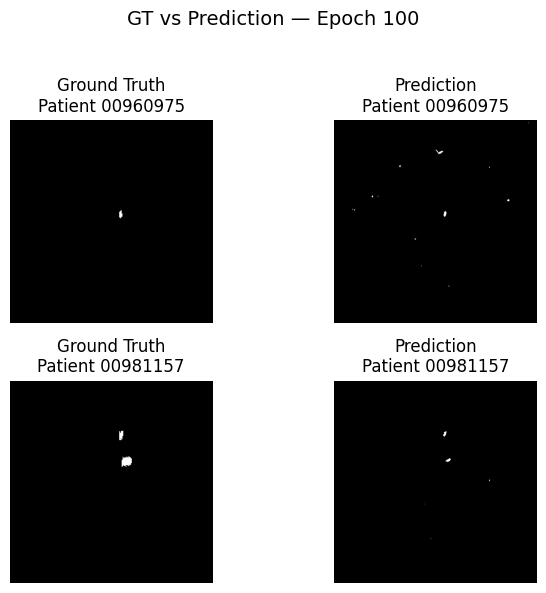

💾 Saved: /content/drive/MyDrive/ms_preprocessed/_visual_results/GT_vs_Pred_epoch100.png
✅ Loaded checkpoint from epoch 200


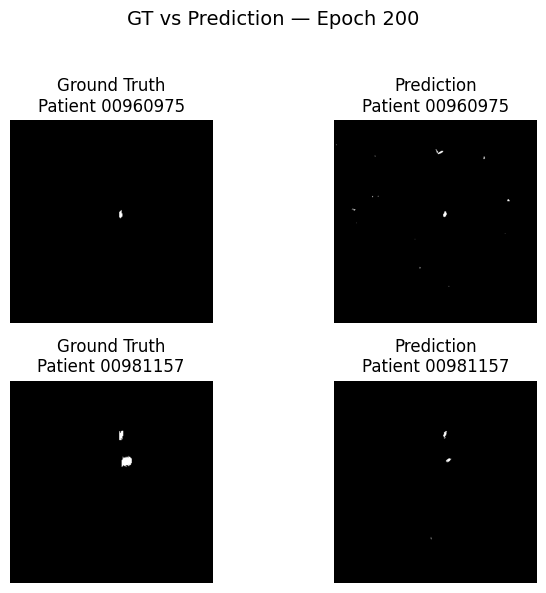

💾 Saved: /content/drive/MyDrive/ms_preprocessed/_visual_results/GT_vs_Pred_epoch200.png


In [ ]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

# ----------------------------------------
# Output directory
# ----------------------------------------
OUT_VIS_DIR = "/content/drive/MyDrive/ms_preprocessed/_visual_results"
os.makedirs(OUT_VIS_DIR, exist_ok=True)

# ----------------------------------------
# Utility: pick best slice
# ----------------------------------------
def best_slice_from_gt(gt, pred=None):
    z_gt = gt.sum(axis=(1, 2))
    if z_gt.max() > 0:
        return int(np.argmax(z_gt))

    if pred is not None:
        z_pr = pred.sum(axis=(1, 2))
        if z_pr.max() > 0:
            return int(np.argmax(z_pr))

    return gt.shape[0] // 2


# ----------------------------------------
# Load model checkpoint
# ----------------------------------------
def load_checkpoint(epoch):
    ckpt_path = f"/content/drive/MyDrive/ms_preprocessed/_checkpoints/unet_epoch{epoch}.pt"
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model_state"])
    model.eval()
    print(f"✅ Loaded checkpoint from epoch {epoch}")


# ----------------------------------------
# Professor-style plot (GT vs Prediction)
# ----------------------------------------
def plot_professor_style(pids, epoch, thr=0.5):
    fig, axes = plt.subplots(len(pids), 2, figsize=(7, 3 * len(pids)))

    if len(pids) == 1:
        axes = np.array([axes])

    for i, pid in enumerate(pids):
        b, f, gt = load_preprocessed(pid)
        prob = sliding_window_predict(
            b, f,
            patch_size=PATCH_SIZE,
            stride=STRIDE
        )
        pred = (prob >= thr).astype(np.uint8)

        sl = best_slice_from_gt(gt, pred)

        # Ground Truth
        axes[i, 0].imshow(gt[sl], cmap="gray")
        axes[i, 0].set_title(f"Ground Truth\nPatient {pid}")
        axes[i, 0].axis("off")

        # Prediction
        axes[i, 1].imshow(pred[sl], cmap="gray")
        axes[i, 1].set_title(f"Prediction\nPatient {pid}")
        axes[i, 1].axis("off")

    plt.suptitle(f"GT vs Prediction — Epoch {epoch}", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    save_path = os.path.join(
        OUT_VIS_DIR,
        f"GT_vs_Pred_epoch{epoch}.png"
    )
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

    print("💾 Saved:", save_path)


# ----------------------------------------
# Generate figures
# ----------------------------------------
TEST_PATIENTS = ["00960975", "00981157"]
EPOCHS_TO_PLOT = [50, 100, 200]

for ep in EPOCHS_TO_PLOT:
    load_checkpoint(ep)
    plot_professor_style(TEST_PATIENTS, epoch=ep, thr=0.5)
